In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.join(os.getcwd(), '..', 'parameters'))
sys.path.insert(0, os.getcwd())

from analysis_utils import (
    load_best_runs, load_all_runs, extract_history, add_wall_times,
    plot_convergence_curves, plot_speedrun_results,
    plot_best_of_budget,
    print_ranking_table, print_variant_comparison,
    print_variant_comparison_allruns, print_offdiag_ranking,
    bootstrap_best_run_ci, print_topk_comparison, print_robustness_table,
    print_best_hyperparameters, save_best_hyperparameters,
    get_optimizer_colors, ema,
    TASK_CONFIGS,
)

plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

BACKEND = "local"
RESULTS_DIR = os.path.join('..', '..', 'results')

In [2]:
def load_task(task_key):
    """Load all data for a task. Returns (cfg, best_runs, all_runs, smoothed_data, raw_data, colors)."""
    cfg = TASK_CONFIGS[task_key]
    colors = get_optimizer_colors(cfg['optimizers'])

    best_runs = load_best_runs(
        backend=BACKEND, optimizers=cfg['optimizers'],
        task_tag=cfg['task_tag'], results_dir=RESULTS_DIR,
        metric_key=cfg['metric_key'], direction=cfg['direction'],
        sort_metric=cfg['sort_metric'], sort_order=cfg['sort_order'],
        iteration=cfg['iteration'],
    )
    all_runs = load_all_runs(
        backend=BACKEND, optimizers=cfg['optimizers'],
        task_tag=cfg['task_tag'], results_dir=RESULTS_DIR,
        iteration=cfg['iteration'],
    )
    raw_data = extract_history(BACKEND, best_runs, cfg['history_metrics'])
    add_wall_times(raw_data)

    smoothed = {}
    for opt, data in raw_data.items():
        d = dict(data)
        for key, fn in cfg.get('y_transforms', {}).items():
            d[key] = fn(d)
        for key in cfg['y_keys']:
            if key in d and len(d[key]) > 0:
                d[key] = ema(np.asarray(d[key], dtype=float))
        smoothed[opt] = d

    return cfg, best_runs, all_runs, smoothed, raw_data, colors


def show_results(cfg, best_runs, all_runs, smoothed, raw_data, colors):
    """Plot all results for a single task."""
    name = cfg['display_name']
    itr = cfg['iteration']

    # --- Training curves ---
    fig = plot_convergence_curves(
        smoothed, y_keys=cfg['y_keys'], x_keys=['epoch', 'wall_times'],
        mark_best=False, colors=colors, highlight=cfg.get('highlight'),
        y_labels=cfg.get('y_labels'),
        x_labels={'epoch': 'Epoch', 'wall_times': 'Wall Time (s)'},
        log_y=cfg.get('log_y', 'auto'),
    )
    for ax in fig.axes:
        for yk, lims in cfg.get('ylim', {}).items():
            if ax.get_ylabel() == cfg.get('y_labels', {}).get(yk, yk):
                ax.set_ylim(*lims)
    plt.tight_layout()
    plt.show()

    # --- Speedrun ---
    fig = plot_speedrun_results(
        raw_data, cfg['speedrun_targets'],
        metric_key=cfg['speedrun_metric'],
        direction=cfg['speedrun_direction'], colors=colors,
    )
    plt.show()

    # --- Rankings & statistics ---
    print_ranking_table(best_runs, metric_key=cfg['metric_key'],
                        direction=cfg['direction'],
                        title=f'{name} (itr {itr}) — Optimizer Ranking')
    print_variant_comparison(best_runs, metric_key=cfg['metric_key'],
                             direction=cfg['direction'],
                             title=f'{name} (itr {itr}) — Variant Pairs (Best Run)')
    print_variant_comparison_allruns(all_runs, metric_key=cfg['metric_key'],
                                     direction=cfg['direction'],
                                     title=f'{name} (itr {itr}) — Variant Comparison (All Runs)')
    print_offdiag_ranking(best_runs, metric_key=cfg['metric_key'],
                          direction=cfg['direction'],
                          title=f'{name} (itr {itr}) — Off-Diagonal (a,b) Ranking')
    bootstrap_best_run_ci(all_runs, metric_key=cfg['metric_key'],
                          direction=cfg['direction'],
                          title=f'{name} (itr {itr}) — Bootstrap 95% CI')
    print_topk_comparison(all_runs, metric_key=cfg['metric_key'],
                          direction=cfg['direction'],
                          title=f'{name} (itr {itr}) — Top-k Mean Comparison')
    print_robustness_table(all_runs, metric_key=cfg['metric_key'],
                           direction=cfg['direction'],
                           title=f'{name} (itr {itr}) — Robustness Metrics')

    # --- Best-of-budget ---
    fig = plot_best_of_budget(
        all_runs, metric_key=cfg['metric_key'],
        direction=cfg['direction'], colors=colors,
        title=f'{name} (itr {itr}) — Best-of-Budget',
    )
    plt.show()

    # --- HP export ---
    print_best_hyperparameters(best_runs)
    filename = f"best_hyperparameters_{cfg['task_tag']}_itr_{itr}.csv"
    save_best_hyperparameters(best_runs, filename)

# MNIST MLP

Finding best run for adam...


  adam: run_167
Finding best run for adamw...
  adamw: run_970
Finding best run for sgd...
  sgd: run_98
Finding best run for muon...
  muon: run_13
Finding best run for sgd_metric...
  sgd_metric: run_404
Finding best run for sgd_log_metric...


  sgd_log_metric: run_668
Finding best run for sgd_rms...
  sgd_rms: run_391
Finding best run for sgd_learn_scalar...
  sgd_learn_scalar: run_317
Finding best run for sgd_learn_scalar_log...
  sgd_learn_scalar_log: run_488
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_304
Finding best run for sgd_learn_diag_log...


  sgd_learn_diag_log: run_488
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_202
Finding best run for sgd_learn_diag_curv_log...
  sgd_learn_diag_curv_log: run_7
Finding best run for sgd_newton_diag...
  sgd_newton_diag: No runs found
Finding best run for sgd_offdiag_0_l...
  sgd_offdiag_0_l: run_79
Finding best run for sgd_offdiag_0_m...
  sgd_offdiag_0_m: run_621
Finding best run for sgd_offdiag_0_theta...


  sgd_offdiag_0_theta: run_794
Finding best run for sgd_offdiag_l_0...
  sgd_offdiag_l_0: run_179
Finding best run for sgd_offdiag_l_l...
  sgd_offdiag_l_l: run_687
Finding best run for sgd_offdiag_l_m...
  sgd_offdiag_l_m: run_687
Finding best run for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: run_638
Finding best run for sgd_offdiag_m_0...


...

  sgd_offdiag_theta_l: run_517
Finding best run for sgd_offdiag_theta_m...
  sgd_offdiag_theta_m: run_638
Finding best run for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: run_638
Loading all runs for adam...
  adam: 1000 runs
Loading all runs for adamw...
  adamw: 1000 runs
Loading all runs for sgd...
  sgd: 1000 runs
Loading all runs for muon...


  muon: 1000 runs
Loading all runs for sgd_metric...
  sgd_metric: 1000 runs
Loading all runs for sgd_log_metric...
  sgd_log_metric: 1000 runs
Loading all runs for sgd_rms...
  sgd_rms: 1000 runs
Loading all runs for sgd_learn_scalar...
  sgd_learn_scalar: 1000 runs
Loading all runs for sgd_learn_scalar_log...
  sgd_learn_scalar_log: 1000 runs
Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 1000 runs
Loading all runs for sgd_learn_diag_log...
  sgd_learn_diag_log: 1000 runs
Loading all runs for sgd_learn_diag_curv...


  sgd_learn_diag_curv: 1000 runs
Loading all runs for sgd_learn_diag_curv_log...
  sgd_learn_diag_curv_log: 1000 runs
Loading all runs for sgd_newton_diag...
  sgd_newton_diag: 0 runs
Loading all runs for sgd_offdiag_0_l...
  sgd_offdiag_0_l: 1000 runs
Loading all runs for sgd_offdiag_0_m...
  sgd_offdiag_0_m: 1000 runs
Loading all runs for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: 1000 runs
Loading all runs for sgd_offdiag_l_0...
  sgd_offdiag_l_0: 1000 runs
Loading all runs for sgd_offdiag_l_l...
  sgd_offdiag_l_l: 1000 runs
Loading all runs for sgd_offdiag_l_m...
  sgd_offdiag_l_m: 1000 runs
Loading all runs for sgd_offdiag_l_theta...


  sgd_offdiag_l_theta: 1000 runs
Loading all runs for sgd_offdiag_m_0...
  sgd_offdiag_m_0: 1000 runs
Loading all runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 1000 runs
Loading all runs for sgd_offdiag_m_m...
  sgd_offdiag_m_m: 1000 runs
Loading all runs for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: 1000 runs
Loading all runs for sgd_offdiag_theta_0...
  sgd_offdiag_theta_0: 1000 runs
Loading all runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 1000 runs
Loading all runs for sgd_offdiag_theta_m...


  sgd_offdiag_theta_m: 1000 runs
Loading all runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 1000 runs
Processing adam...
Processing adamw...
Processing sgd...
Processing muon...
Processing sgd_metric...
Processing sgd_log_metric...
Processing sgd_rms...
Processing sgd_learn_scalar...
Processing sgd_learn_scalar_log...
Processing sgd_learn_diag...
Processing sgd_learn_diag_log...
Processing sgd_learn_diag_curv...
Processing sgd_learn_diag_curv_log...
Processing sgd_offdiag_0_l...
Processing sgd_offdiag_0_m...
Processing sgd_offdiag_0_theta...
Processing sgd_offdiag_l_0...
Processing sgd_offdiag_l_l...
Processing sgd_offdiag_l_m...
Processing sgd_offdiag_l_theta...
Processing sgd_offdiag_m_0...
Processing sgd_offdiag_m_l...
Processing sgd_offdiag_m_m...
Processing sgd_offdiag_m_theta...
Processing sgd_offdiag_theta_0...
Processing sgd_offdiag_theta_l...
Processing sgd_offdiag_theta_m...
Processing sgd_offdiag_theta_theta...


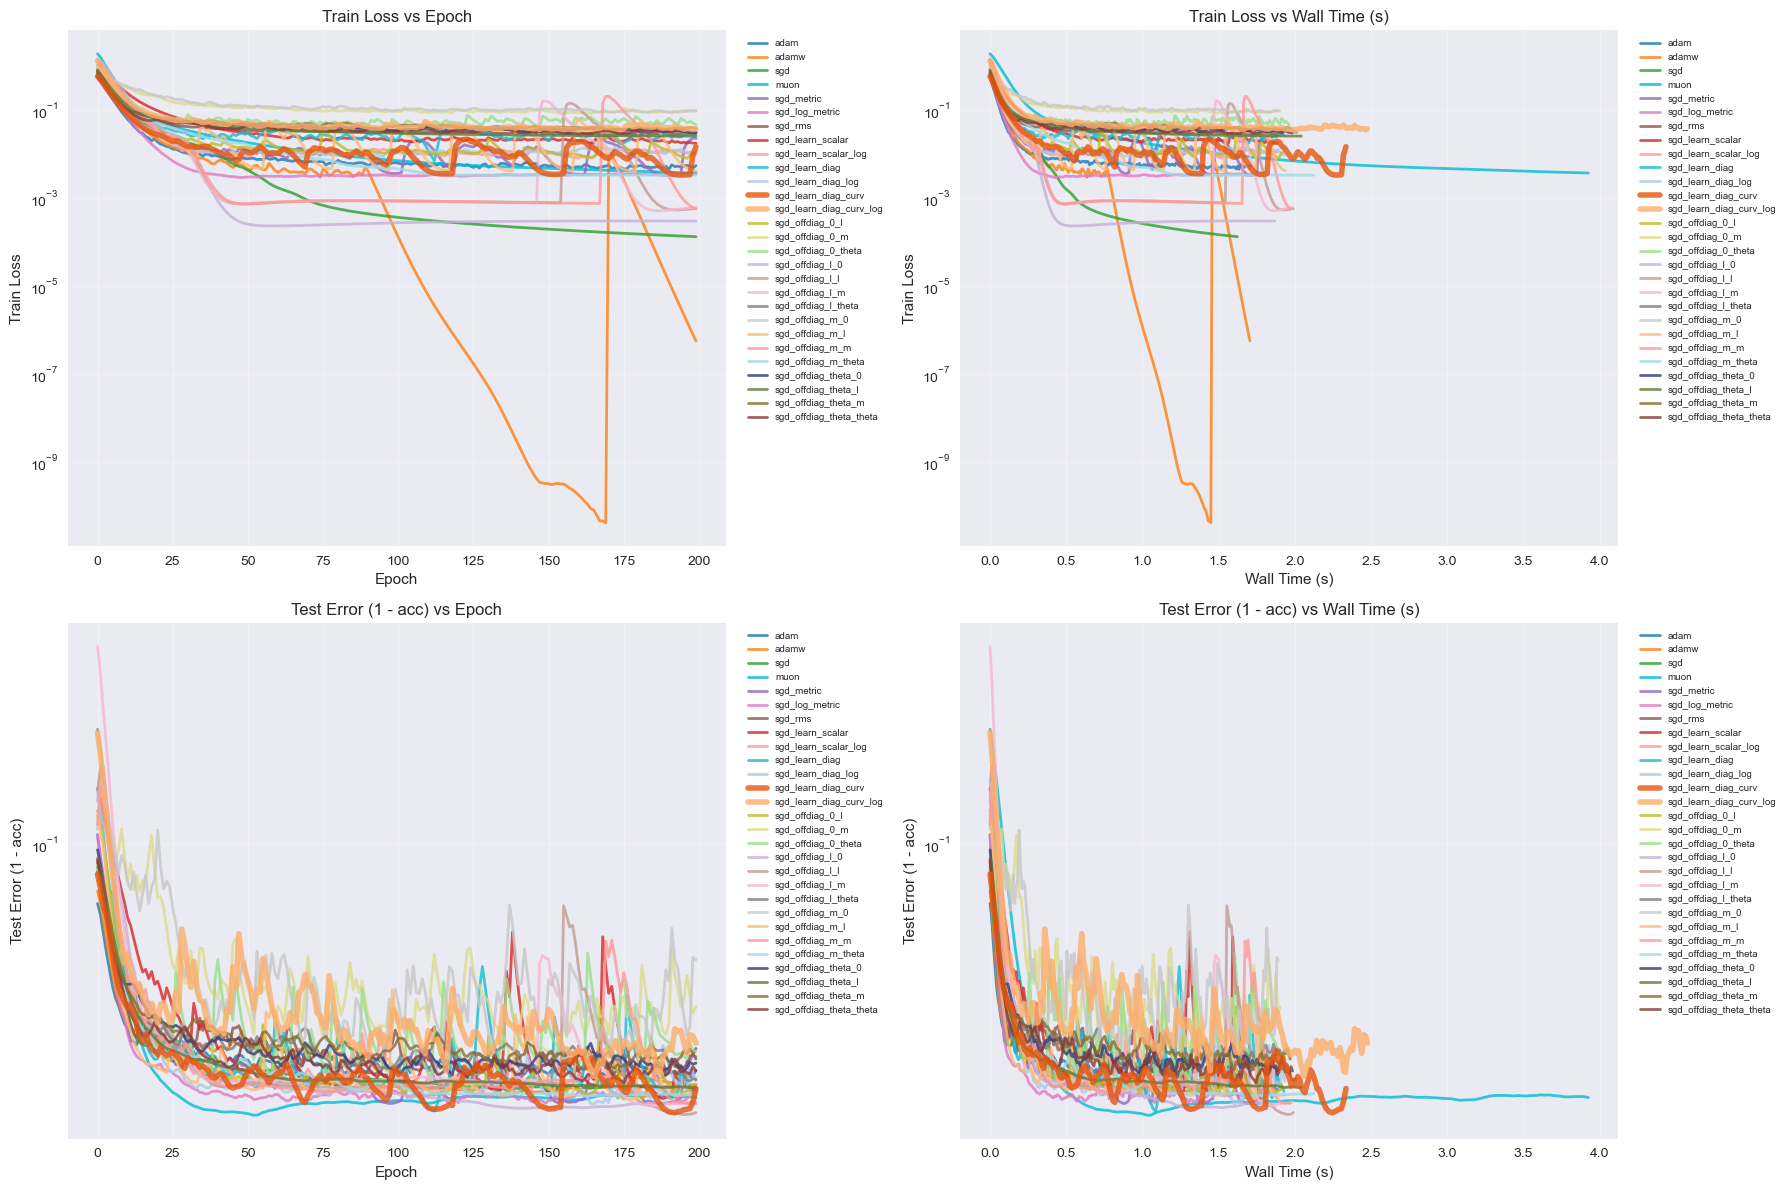

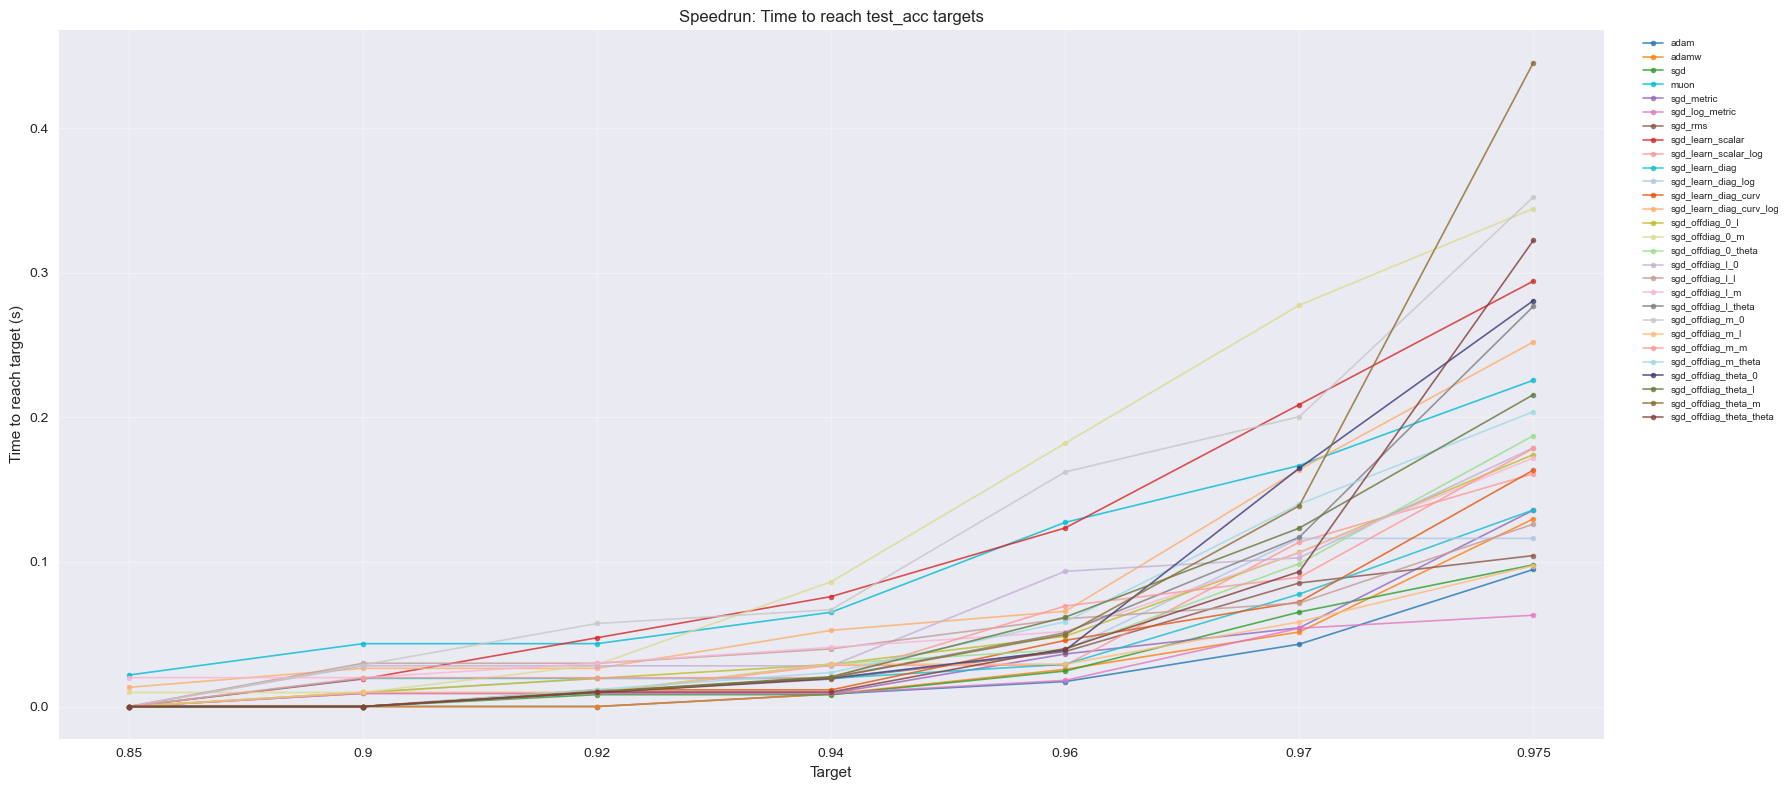


MNIST MLP (itr 4) — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     sgd_learn_diag                -0.984100           
2     muon                          -0.983900           
3     sgd_learn_scalar_log          -0.983900           
4     sgd_learn_diag_curv           -0.983900           
5     sgd_learn_diag_curv_log       -0.983800           
6     sgd_log_metric                -0.983700           
7     sgd_offdiag_l_l               -0.983700           
8     sgd_learn_diag_log            -0.983600           
9     sgd_metric                    -0.983400           
10    sgd_rms                       -0.983000           
11    sgd_offdiag_l_0               -0.983000           
12    sgd_learn_scalar              -0.982700           
13    sgd_offdiag_l_m               -0.982700           
14    sgd_offdiag_m_l               -0.982700           
15    sgd_offdiag_0_l               -0.982600    

sgd                           -0.980400   -0.980400   -0.979800   1000    
muon                          -0.983900   -0.983900   -0.983400   1000    
sgd_metric                    -0.983400   -0.983400   -0.981400   1000    


sgd_log_metric                -0.983700   -0.983700   -0.982600   1000    
sgd_rms                       -0.983000   -0.983000   -0.981600   1000    
sgd_learn_scalar              -0.982700   -0.982700   -0.981100   1000    


sgd_learn_scalar_log          -0.983900   -0.983900   -0.982500   1000    
sgd_learn_diag                -0.984100   -0.984100   -0.982200   1000    
sgd_learn_diag_log            -0.983600   -0.983600   -0.982900   1000    


sgd_learn_diag_curv           -0.983900   -0.983900   -0.981700   1000    
sgd_learn_diag_curv_log       -0.983800   -0.983800   -0.982300   1000    
sgd_offdiag_0_l               -0.982600   -0.982600   -0.981600   1000    


...

sgd_offdiag_l_l               -0.983700   -0.983700   -0.981000   1000    
sgd_offdiag_l_m               -0.982700   -0.982700   -0.981500   1000    
sgd_offdiag_l_theta           -0.981900   -0.981900   -0.980800   1000    


sgd_offdiag_m_0               -0.981800   -0.981800   -0.981300   1000    
sgd_offdiag_m_l               -0.982700   -0.982700   -0.982100   1000    
sgd_offdiag_m_m               -0.982600   -0.982600   -0.982000   1000    


sgd_offdiag_m_theta           -0.981600   -0.981600   -0.980800   1000    
sgd_offdiag_theta_0           -0.980100   -0.980100   -0.978100   1000    


sgd_offdiag_theta_l           -0.980500   -0.980500   -0.978500   1000    
sgd_offdiag_theta_m           -0.980400   -0.980400   -0.979200   1000    
sgd_offdiag_theta_theta       -0.981600   -0.981600   -0.979000   1000    


MNIST MLP (itr 4) — Top-k Mean Comparison
Optimizer                     top-1         top-5         top-10        top-50        n_runs  
----------------------------------------------------------------------------------------------
sgd_learn_diag                -0.984100     -0.982980     -0.982120     -0.980118     1000    
muon                          -0.983900     -0.983540     -0.983140     -0.981932     1000    
sgd_learn_scalar_log          -0.983900     -0.983000     -0.982420     -0.980900     1000    
sgd_learn_diag_curv           -0.983900     -0.982620     -0.981890     -0.979868     1000    
sgd_learn_diag_curv_log       -0.983800     -0.982940     -0.982460     -0.980882     1000    
sgd_log_metric                -0.983700     -0.983000     -0.98261


MNIST MLP (itr 4) — Robustness Metrics
  Failure threshold: -0.098000 (> = failure)
Optimizer                     Median      Q1          Q3          IQR         Fail%   n       
----------------------------------------------------------------------------------------------
adam                          -0.947300   -0.975000   -0.310250   0.664750    0.0%    1000    
adamw                         -0.946300   -0.974825   -0.300550   0.674275    0.0%    1000    
sgd_rms                       -0.945100   -0.975000   -0.750525   0.224475    1.2%    1000    
muon                          -0.937250   -0.978700   -0.343550   0.635150    0.5%    1000    
sgd_learn_scalar_log          -0.889600   -0.972150   -0.252800   0.719350    5.7%    1000    
sgd_learn_scalar              -0.889100   -0.966900   -0.315825   0.651075    5.7%    1000    
sgd_learn_diag                -0.865700   -0.958125   -0.232450   0.725675    7.4%    1000    
sgd_learn_diag_log            -0.846250   -0.971050   -0.180

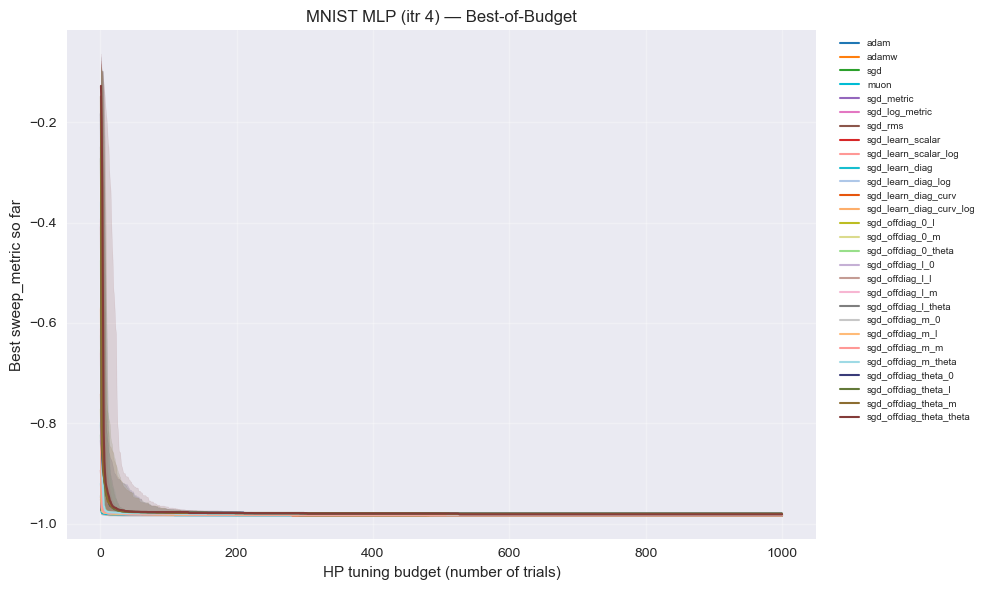

Hyperparameters for Best Runs

ADAM:
  Run name: run_167
  Config:
    learning_rate: 0.0056581514044715476
    beta1: 0.3064323401234645
    beta2: 0.9626776244394191
    eps: 1e-08
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.3001267910003662
  sweep_metric: -0.980900
  final_max_val_acc: 0.980900
----------------------------------------

ADAMW:
  Run name: run_970
  Config:
    learning_rate: 0.0032884482376342094
    beta1: 0.7241714961060847
    beta2: 0.9915277899829948
    eps: 1e-08
    weight_decay: 1.2654063842163958e-05
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.29261255264282227
  sweep_metric: -0.981200
  final_max_val_acc: 0.981200
----------------------------------------

SGD:
  Run name: run_98
  Config:
    learning_rate: 0.12069513145865542
    momentum: 0.8881391573530513
    batch_size: 1024
    architecture: MLP
    val_time_seconds: 0.30144667625427246
  sweep_metric: -0.980400
  final_max_val_acc: 0.980400
-----------

In [3]:
mnist = load_task("mnist_mlp")
show_results(*mnist)

# CIFAR-10 ResNet-18

Finding best run for adam...
  adam: No runs found
Finding best run for adamw...
  adamw: No runs found
Finding best run for sgd...
  sgd: No runs found
Finding best run for sgd_metric...
  sgd_metric: No runs found
Finding best run for sgd_log_metric...
  sgd_log_metric: No runs found
Finding best run for muon...
  muon: No runs found
Finding best run for sgd_rms...
  sgd_rms: No runs found
Loading all runs for adam...
  adam: 0 runs
Loading all runs for adamw...
  adamw: 0 runs
Loading all runs for sgd...
  sgd: 0 runs
Loading all runs for sgd_metric...
  sgd_metric: 0 runs
Loading all runs for sgd_log_metric...
  sgd_log_metric: 0 runs
Loading all runs for muon...
  muon: 0 runs
Loading all runs for sgd_rms...
  sgd_rms: 0 runs


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:419: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)


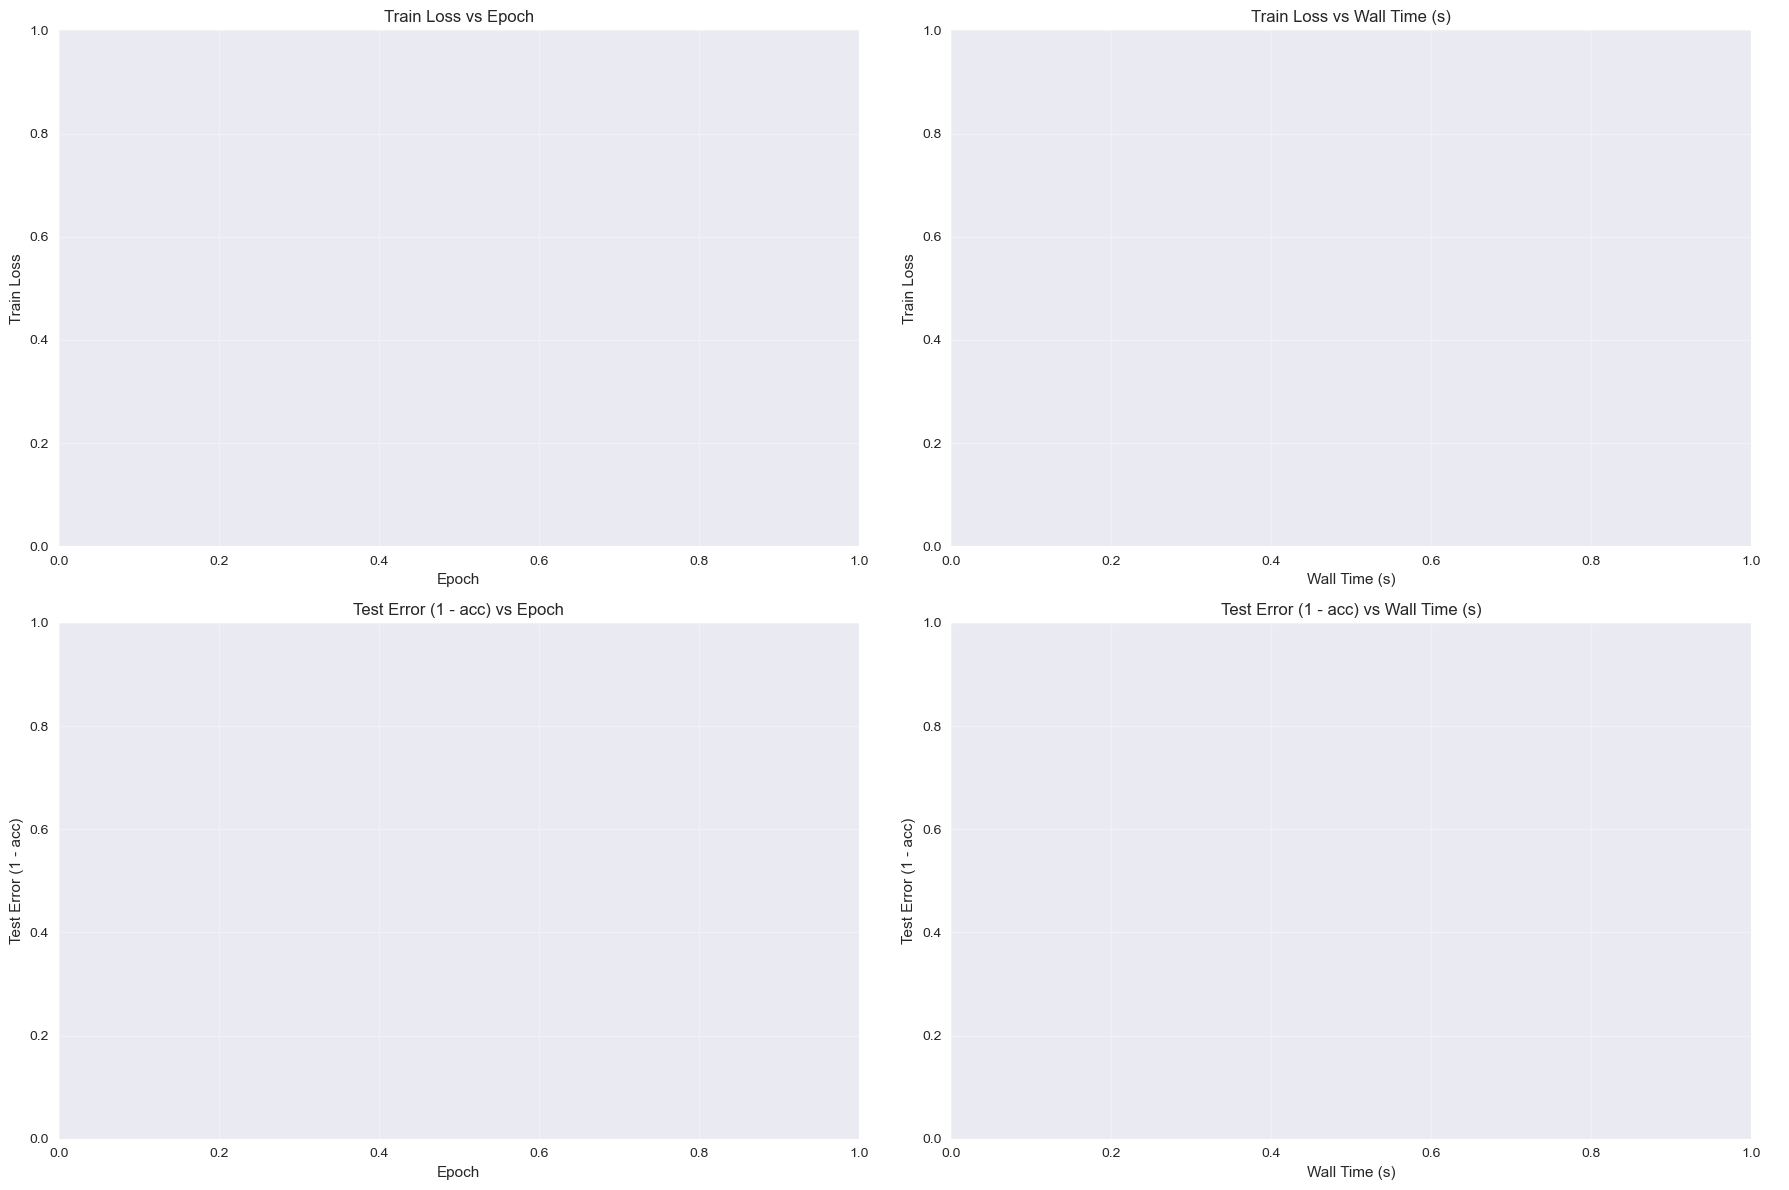

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:671: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


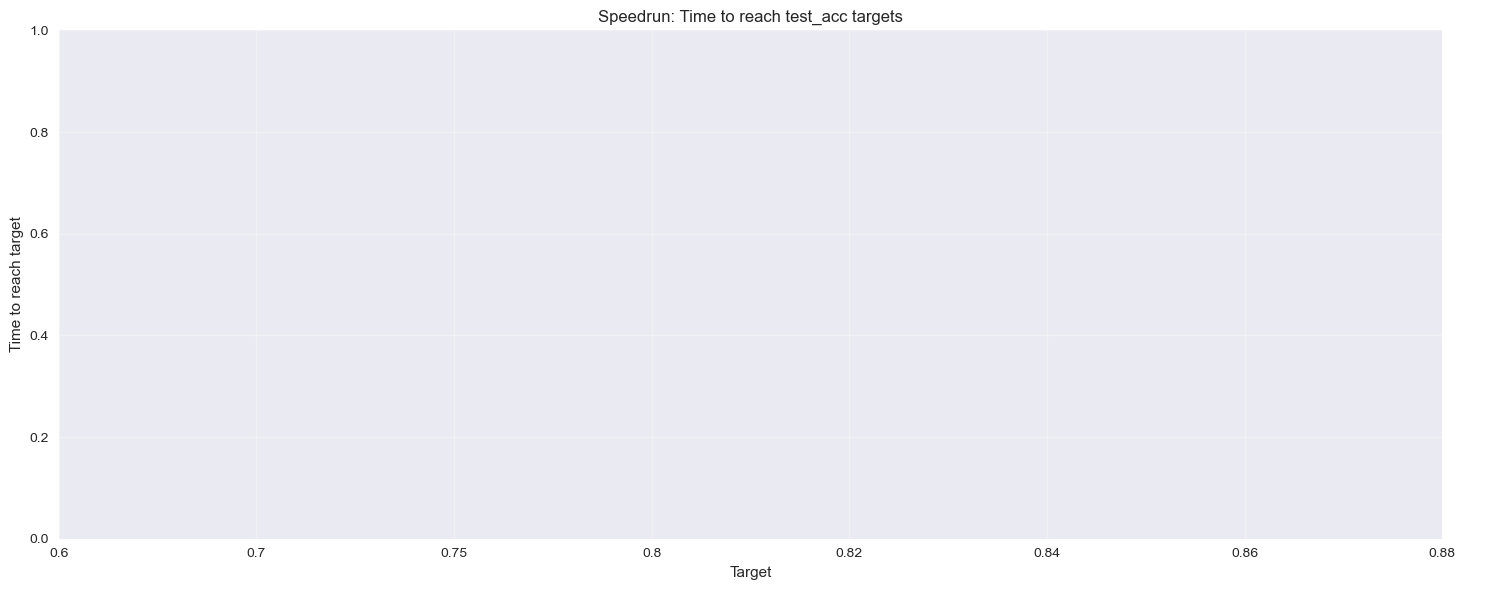


CIFAR-10 ResNet-18 (itr 0) — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------


CIFAR-10 ResNet-18 (itr 0) — Variant Pairs (Best Run)
Comparison                         Base        Variant     Delta       Winner      
-----------------------------------------------------------------------------------


CIFAR-10 ResNet-18 (itr 0) — Variant Comparison (All Runs)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------

  (no off-diagonal optimizers found)

CIFAR-10 ResNet-18 (itr 0) — Bootstrap 95% CI
Optimizer                     Best        CI lo       CI hi       n_runs  
--------------------------------------------------------------------------


CIFAR-10 ResNet-18 (itr 0) — Top-k Mean Comparison
Optimizer                     t

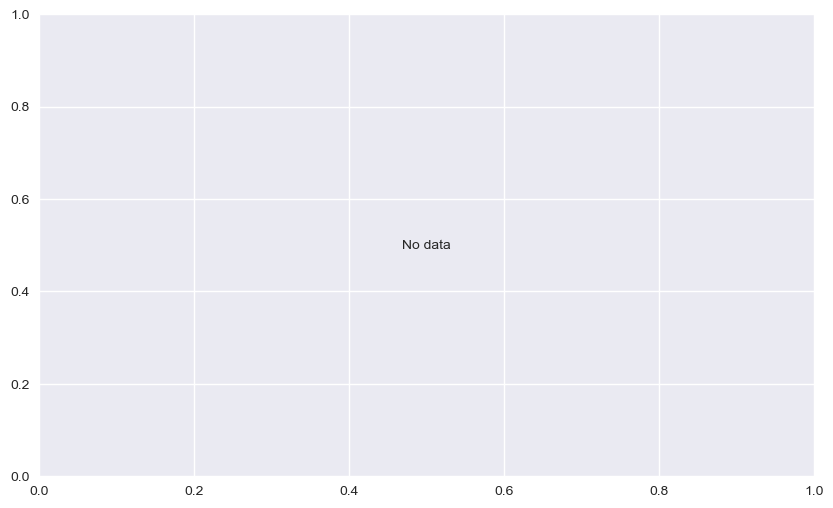

Hyperparameters for Best Runs
Saved hyperparameters to best_hyperparameters_cifar10_resnet18_itr_0.csv


In [4]:
cifar = load_task("cifar10_resnet18")
show_results(*cifar)

# Shakespeare MiniGPT

Finding best run for adam...


  adam: run_77
Finding best run for adamw...


  adamw: run_158
Finding best run for sgd...
  sgd: run_98
Finding best run for muon...
  muon: run_59
Finding best run for sgd_metric...
  sgd_metric: run_115
Finding best run for sgd_log_metric...
  sgd_log_metric: run_115
Finding best run for sgd_rms...
  sgd_rms: run_175
Finding best run for sgd_learn_scalar...
  sgd_learn_scalar: run_30
Finding best run for sgd_learn_scalar_log...
  sgd_learn_scalar_log: run_30
Finding best run for sgd_learn_diag...
  sgd_learn_diag: run_61
Finding best run for sgd_learn_diag_log...
  sgd_learn_diag_log: run_61
Finding best run for sgd_learn_diag_curv...
  sgd_learn_diag_curv: run_155
Finding best run for sgd_learn_diag_curv_log...
  sgd_learn_diag_curv_log: run_155
Finding best run for sgd_newton_diag...
  sgd_newton_diag: No runs found
Finding best run for sgd_offdiag_0_l...


  sgd_offdiag_0_l: run_46
Finding best run for sgd_offdiag_0_m...


  sgd_offdiag_0_m: run_46
Finding best run for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: run_70
Finding best run for sgd_offdiag_l_0...


...

  sgd_offdiag_l_l: run_179
Finding best run for sgd_offdiag_l_m...
  sgd_offdiag_l_m: run_179
Finding best run for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: run_114
Finding best run for sgd_offdiag_m_0...
  sgd_offdiag_m_0: run_46
Finding best run for sgd_offdiag_m_l...
  sgd_offdiag_m_l: run_62
Finding best run for sgd_offdiag_m_m...
  sgd_offdiag_m_m: run_46
Finding best run for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: run_150
Finding best run for sgd_offdiag_theta_0...
  sgd_offdiag_theta_0: run_45
Finding best run for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: run_45
Finding best run for sgd_offdiag_theta_m...
  sgd_offdiag_theta_m: run_45
Finding best run for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: run_45
Loading all runs for adam...
  adam: 200 runs
Loading all runs for adamw...
  adamw: 200 runs
Loading all runs for sgd...
  sgd: 200 runs
Loading all runs for muon...
  muon: 200 runs
Loading all runs for sgd_metric...
  sgd_metric: 200 runs
Loading all 

  sgd_learn_scalar_log: 200 runs


Loading all runs for sgd_learn_diag...
  sgd_learn_diag: 200 runs
Loading all runs for sgd_learn_diag_log...
  sgd_learn_diag_log: 200 runs
Loading all runs for sgd_learn_diag_curv...
  sgd_learn_diag_curv: 200 runs
Loading all runs for sgd_learn_diag_curv_log...


  sgd_learn_diag_curv_log: 200 runs
Loading all runs for sgd_newton_diag...
  sgd_newton_diag: 0 runs
Loading all runs for sgd_offdiag_0_l...
  sgd_offdiag_0_l: 200 runs
Loading all runs for sgd_offdiag_0_m...


  sgd_offdiag_0_m: 200 runs
Loading all runs for sgd_offdiag_0_theta...
  sgd_offdiag_0_theta: 200 runs
Loading all runs for sgd_offdiag_l_0...
  sgd_offdiag_l_0: 200 runs
Loading all runs for sgd_offdiag_l_l...
  sgd_offdiag_l_l: 200 runs
Loading all runs for sgd_offdiag_l_m...
  sgd_offdiag_l_m: 200 runs
Loading all runs for sgd_offdiag_l_theta...
  sgd_offdiag_l_theta: 200 runs
Loading all runs for sgd_offdiag_m_0...
  sgd_offdiag_m_0: 200 runs
Loading all runs for sgd_offdiag_m_l...
  sgd_offdiag_m_l: 200 runs
Loading all runs for sgd_offdiag_m_m...
  sgd_offdiag_m_m: 200 runs
Loading all runs for sgd_offdiag_m_theta...
  sgd_offdiag_m_theta: 200 runs
Loading all runs for sgd_offdiag_theta_0...
  sgd_offdiag_theta_0: 200 runs
Loading all runs for sgd_offdiag_theta_l...
  sgd_offdiag_theta_l: 200 runs
Loading all runs for sgd_offdiag_theta_m...
  sgd_offdiag_theta_m: 200 runs
Loading all runs for sgd_offdiag_theta_theta...
  sgd_offdiag_theta_theta: 200 runs
Processing adam...
Proce

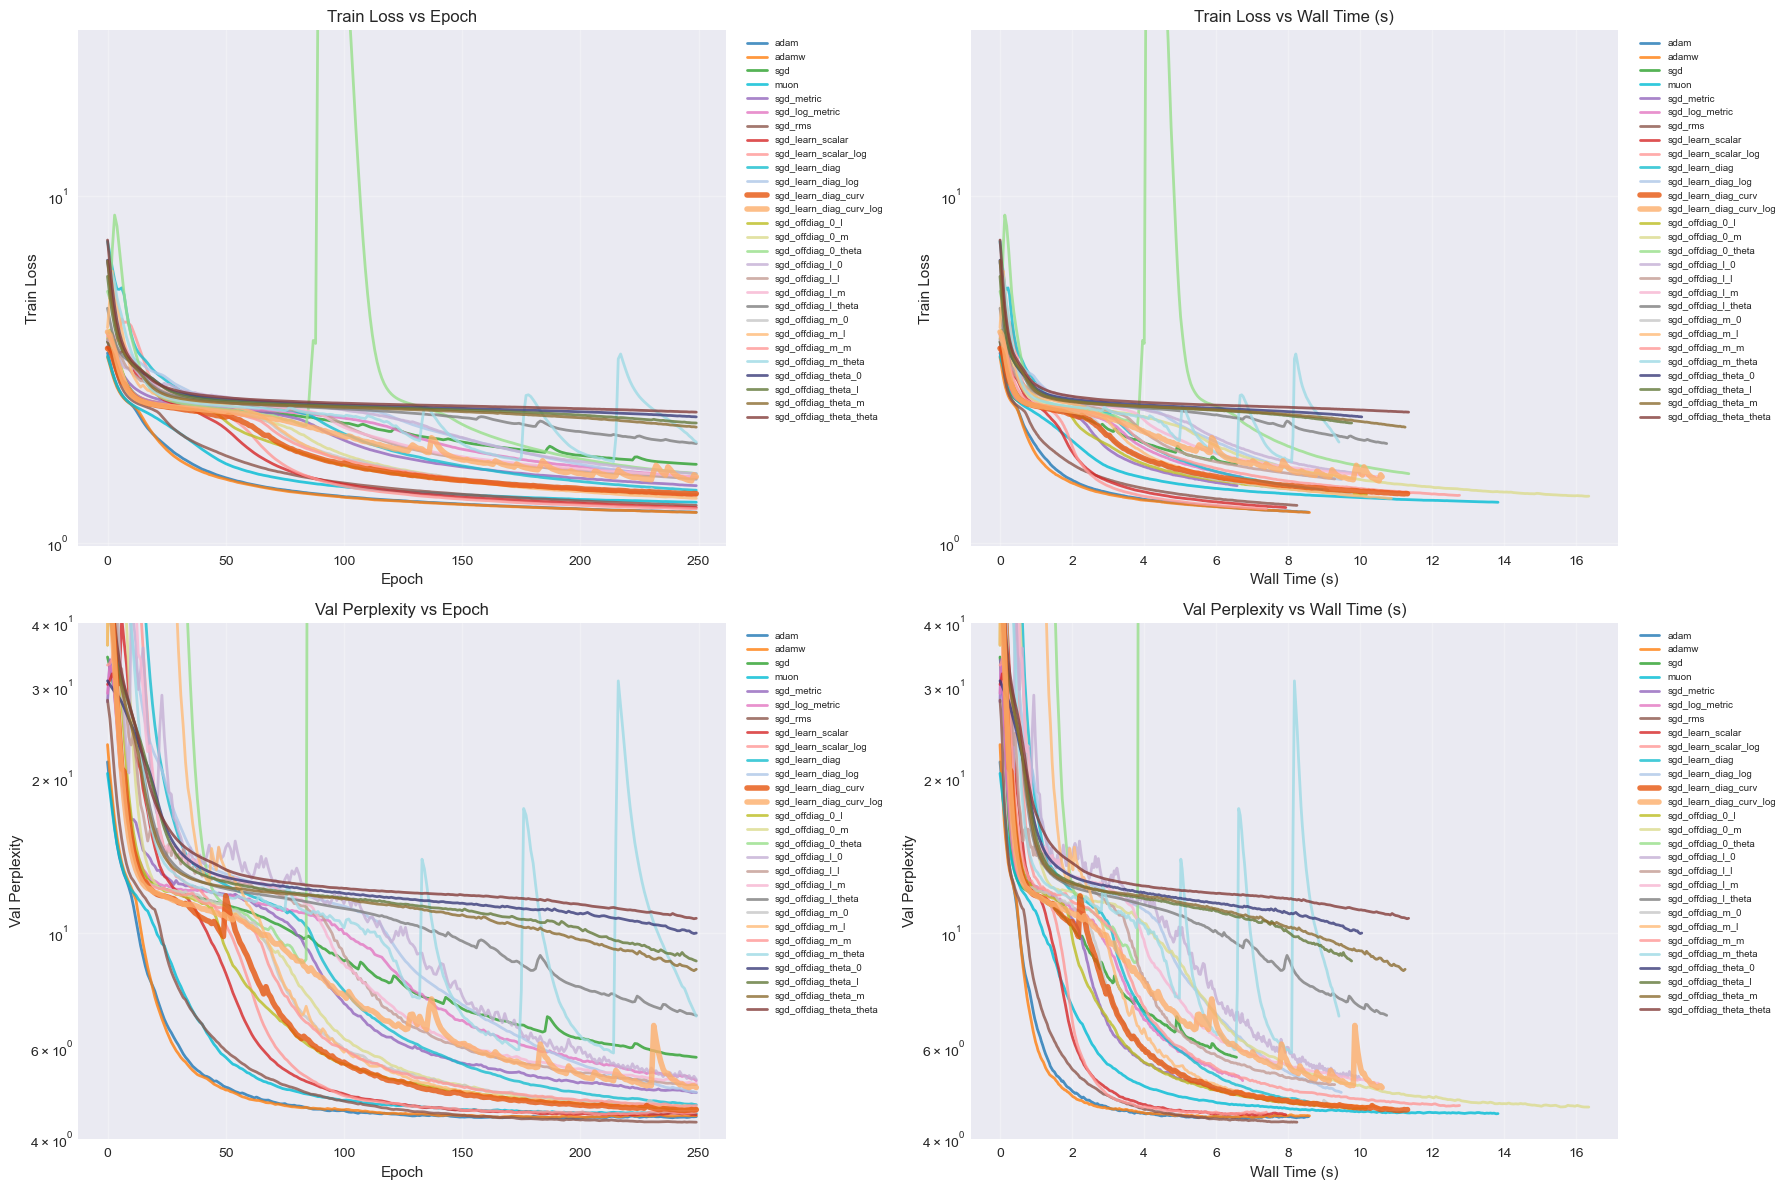

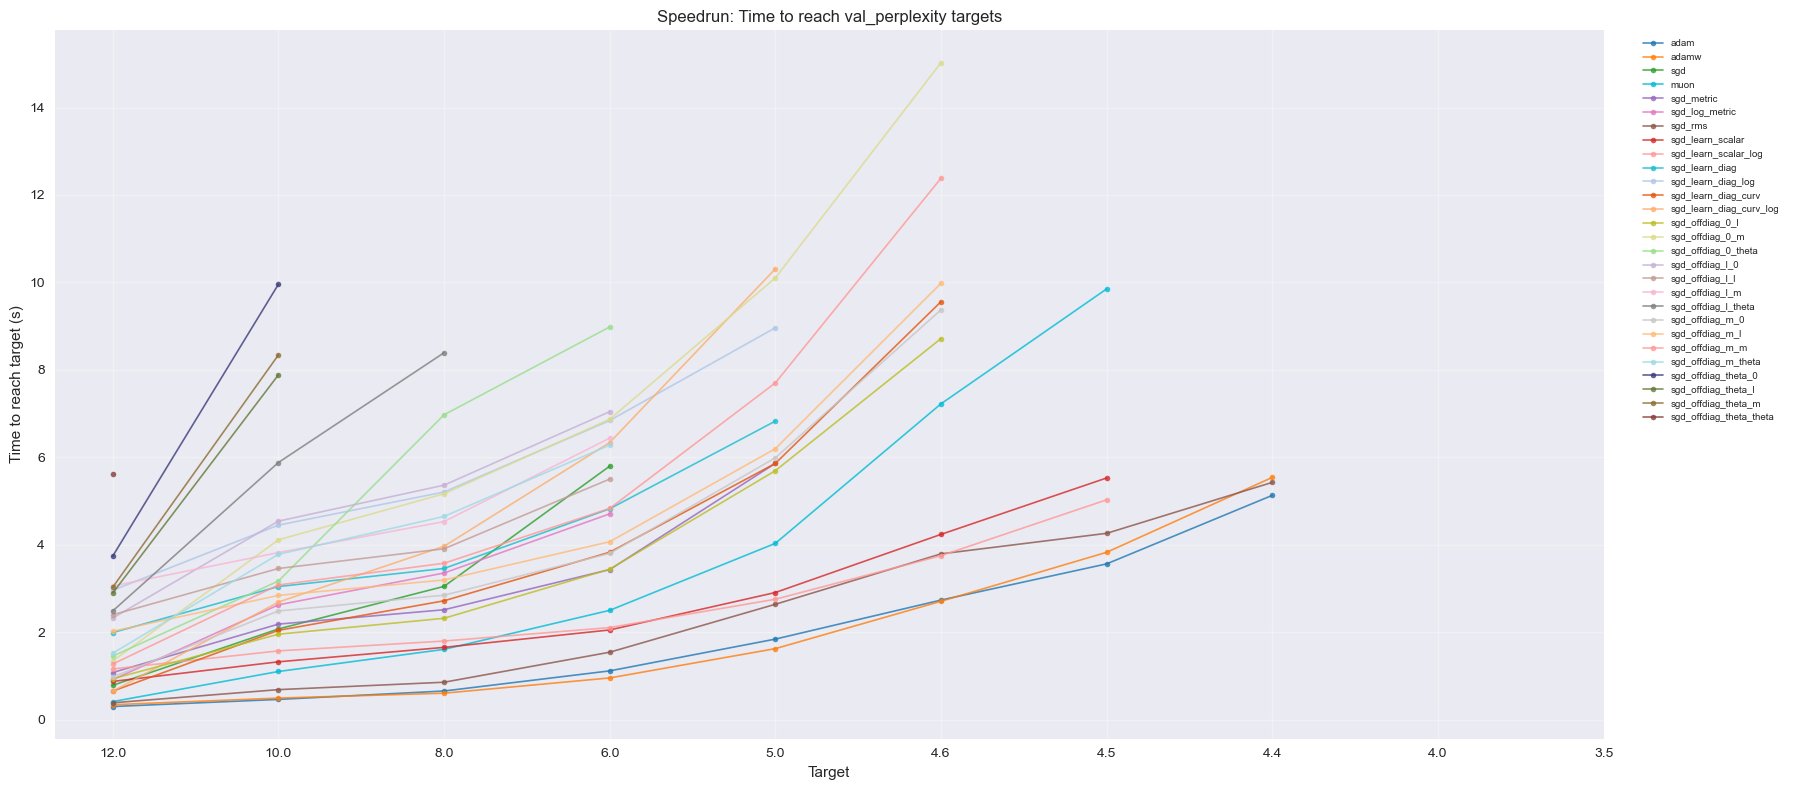


Shakespeare MiniGPT (itr 2) — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------
1     sgd_rms                       4.293023            
2     adam                          4.364747            
3     adamw                         4.384629            
4     sgd_learn_scalar              4.420188            
5     muon                          4.440900            
6     sgd_learn_scalar_log          4.442779            
7     sgd_learn_diag_curv           4.520262            
8     sgd_offdiag_m_l               4.552433            
9     sgd_offdiag_0_l               4.556794            
10    sgd_offdiag_0_m               4.572505            
11    sgd_offdiag_m_0               4.577313            
12    sgd_offdiag_m_m               4.597306            
13    sgd_learn_diag                4.636649            
14    sgd_metric                    4.880633            
15    sgd_learn_diag_log            4.8

muon                          4.440900    4.440900    4.504069    179     
sgd_metric                    4.880633    4.880633    5.271967    200     
sgd_log_metric                5.096527    5.096527    5.385609    200     
sgd_rms                       4.293023    4.293023    4.374439    200     


sgd_learn_scalar              4.420188    4.420188    4.960782    200     
sgd_learn_scalar_log          4.442779    4.442779    5.140994    200     
sgd_learn_diag                4.636649    4.636649    5.330168    200     
sgd_learn_diag_log            4.895627    4.895627    5.160410    200     


sgd_learn_diag_curv           4.520262    4.520262    5.549760    200     
sgd_learn_diag_curv_log       4.937502    4.937502    5.632942    200     
sgd_offdiag_0_l               4.556794    4.556794    5.030941    183     
sgd_offdiag_0_m               4.572505    4.572505    5.011398    180     
sgd_offdiag_0_theta           5.191303    5.191303    7.693333    180     


sgd_offdiag_l_0               5.003794    5.003794    7.051386    151     
sgd_offdiag_l_l               5.055637    5.055637    7.064598    176     
sgd_offdiag_l_m               5.086848    5.086848    7.496958    153     
sgd_offdiag_l_theta           6.886841    6.886841    8.187153    169     


sgd_offdiag_m_0               4.577313    4.577313    5.003603    174     
sgd_offdiag_m_l               4.552433    4.552433    5.270285    167     
sgd_offdiag_m_m               4.597306    4.597306    4.980588    185     
sgd_offdiag_m_theta           5.773856    5.773856    6.882389    181     
sgd_offdiag_theta_0           9.847103    9.847103    11.927032   114     


sgd_offdiag_theta_l           8.756392    8.756392    11.938552   137     
sgd_offdiag_theta_m           8.366138    8.366138    11.993848   125     
sgd_offdiag_theta_theta       10.600431   10.600431   12.556538   182     


Shakespeare MiniGPT (itr 2) — Top-k Mean Comparison
Optimizer                     top-1         top-5         top-10        top-50        n_runs  
----------------------------------------------------------------------------------------------
sgd_rms                       4.293023      4.360436      4.403275      5.491720      200     
adam                          4.364747      4.391243      4.424148      4.754849      166     
adamw                         4.384629      4.400136      4.417033      4.697000      166     
sgd_learn_scalar              4.420188      4.771690      5.080124      9.416851      200     
muon                          4.440900      4.482775      4.504661      4.987964      179     
sgd_learn_scalar_log          4.442779      4.896391    

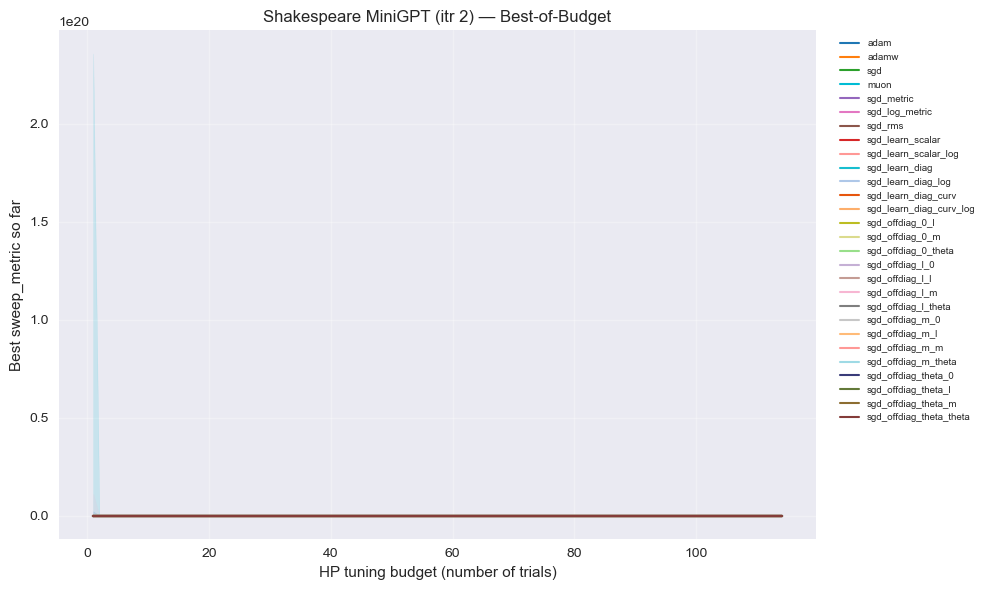

Hyperparameters for Best Runs

ADAM:
  Run name: run_77
  Config:
    learning_rate: 0.003299587515665484
    beta1: 0.5711348457800955
    beta2: 0.8984542869943909
    eps: 1e-08
    batch_size: 256
    architecture: MiniGPT
  sweep_metric: 4.364747
  final_min_val_perplexity: 4.364747
----------------------------------------

ADAMW:
  Run name: run_158
  Config:
    learning_rate: 0.0038171752108588385
    beta1: 0.5267923504126625
    beta2: 0.8214236850668213
    eps: 1e-08
    weight_decay: 0.000172608363137768
    batch_size: 256
    architecture: MiniGPT
  sweep_metric: 4.384629
  final_min_val_perplexity: 4.384629
----------------------------------------

SGD:
  Run name: run_98
  Config:
    learning_rate: 0.12069513145865542
    momentum: 0.8881391573530513
    batch_size: 256
    architecture: MiniGPT
  sweep_metric: 5.736539
  final_min_val_perplexity: 5.736539
----------------------------------------

MUON:
  Run name: run_59
  Config:
    learning_rate: 0.004525877765425

In [5]:
shake = load_task("shakespeare_minigpt")
show_results(*shake)

# Regression

Finding best run for adam...
  adam: No runs found
Finding best run for adamw...
  adamw: No runs found
Finding best run for sgd...
  sgd: No runs found
Finding best run for sgd_metric...
  sgd_metric: No runs found
Finding best run for sgd_log_metric...
  sgd_log_metric: No runs found
Finding best run for muon...
  muon: No runs found
Finding best run for sgd_rms...
  sgd_rms: No runs found
Loading all runs for adam...
  adam: 0 runs
Loading all runs for adamw...
  adamw: 0 runs
Loading all runs for sgd...
  sgd: 0 runs
Loading all runs for sgd_metric...
  sgd_metric: 0 runs
Loading all runs for sgd_log_metric...
  sgd_log_metric: 0 runs
Loading all runs for muon...
  muon: 0 runs
Loading all runs for sgd_rms...
  sgd_rms: 0 runs


/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:419: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)


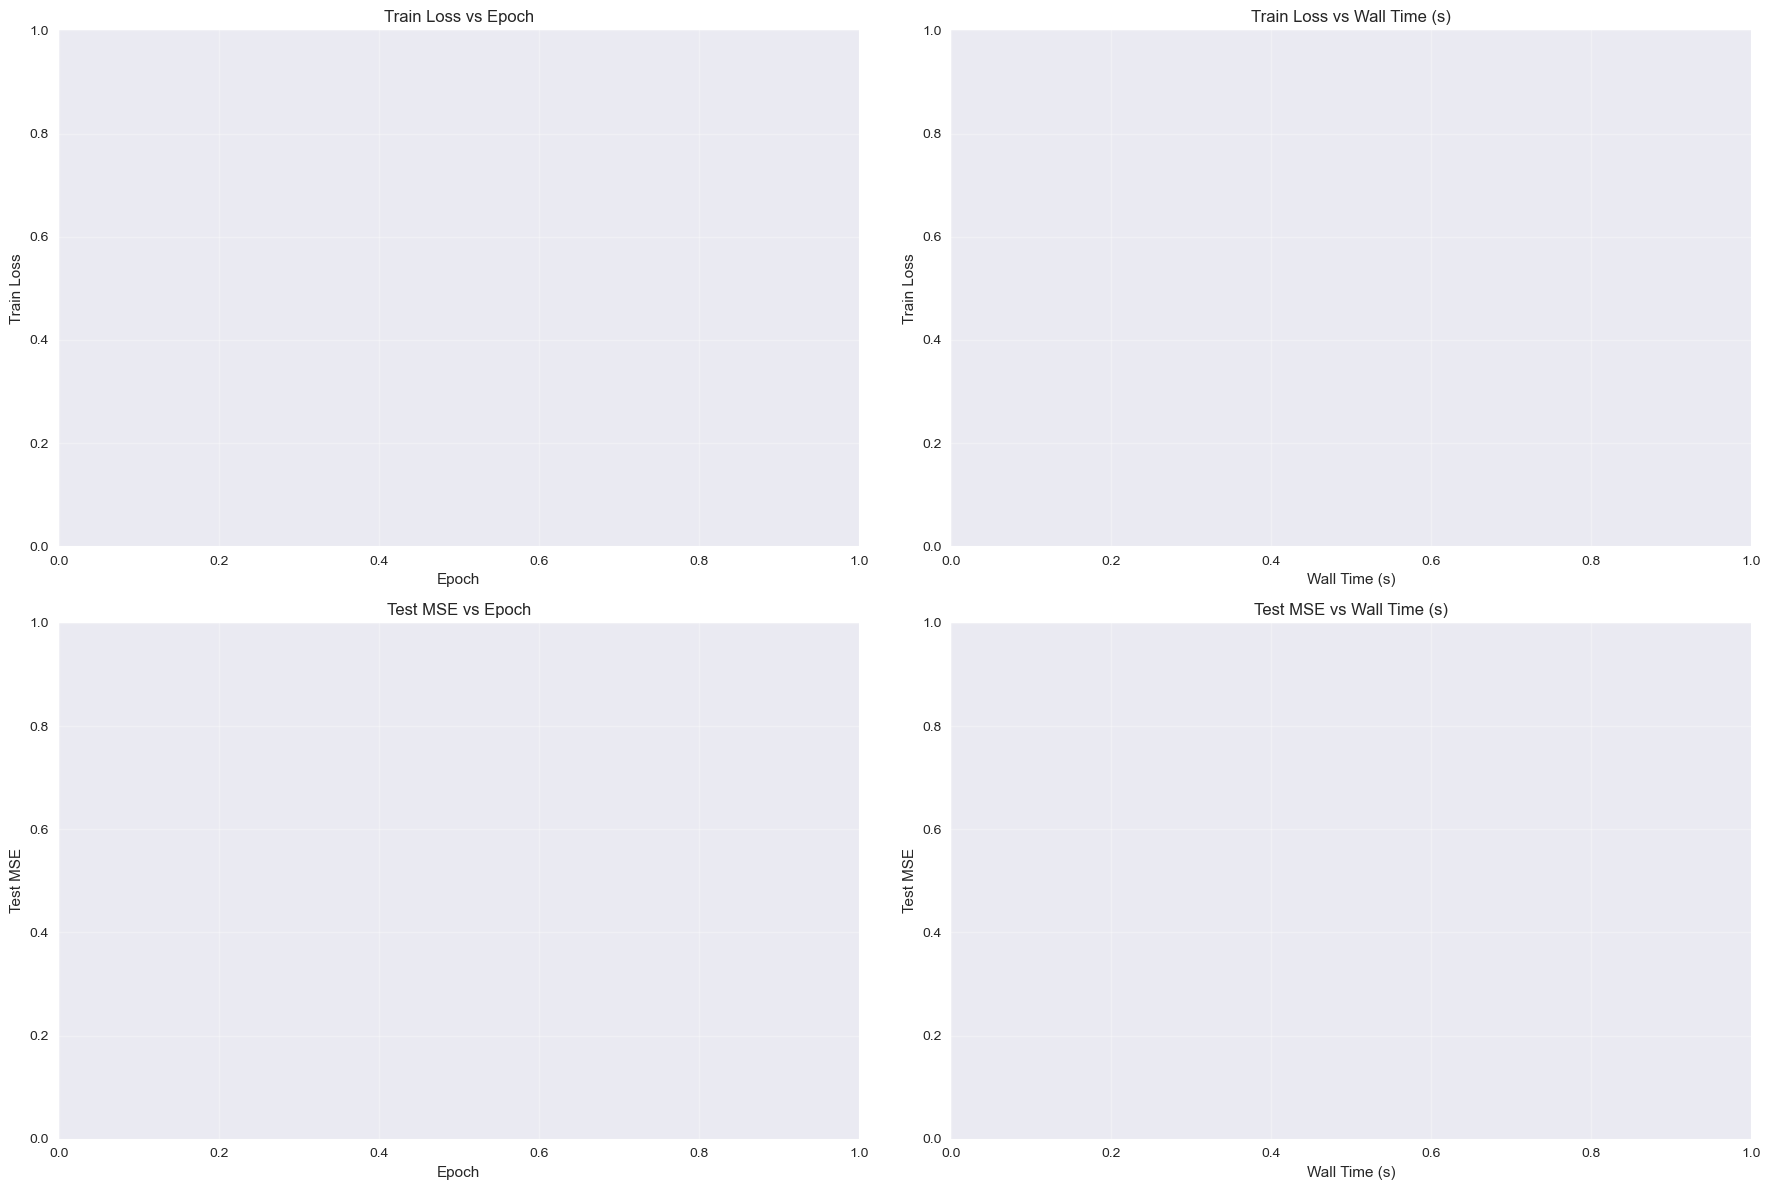

/Users/noah-everett/Library/Mobile Documents/com~apple~CloudDocs/Projects/induced-metric-optimiser/repo/analysis/plots.py:671: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)


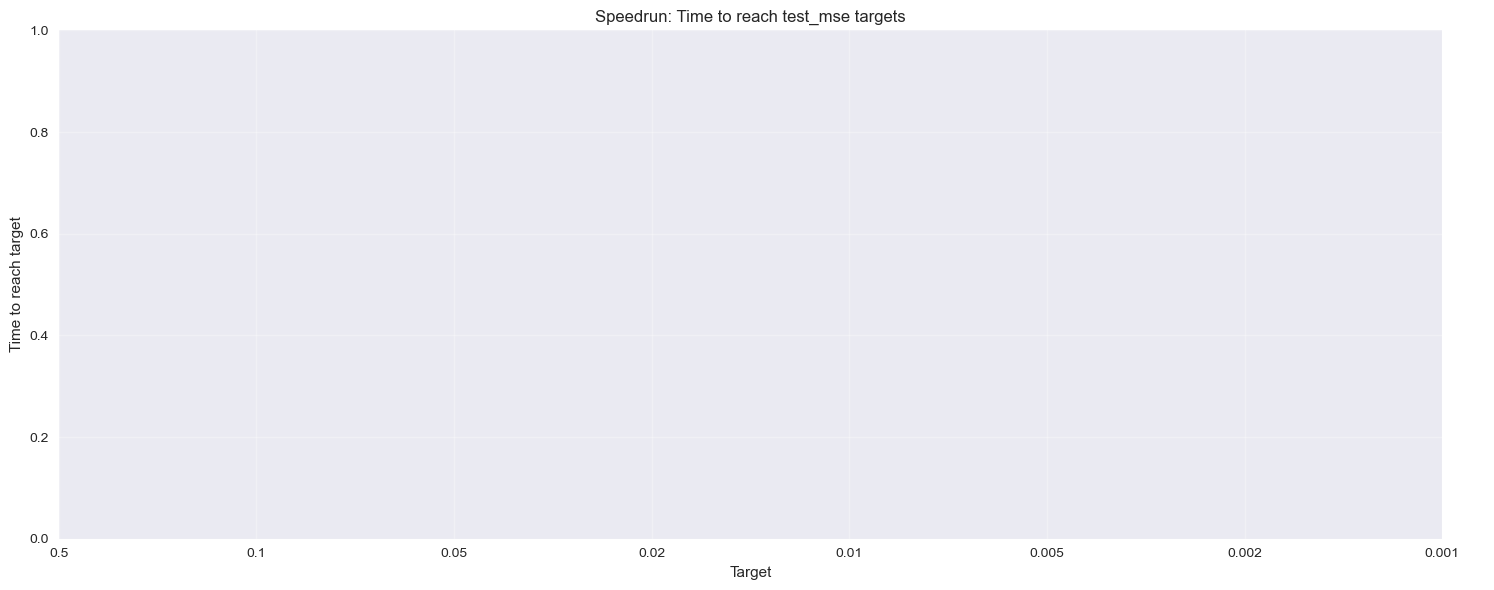


Regression (itr 0) — Optimizer Ranking
Rank  Optimizer                     sweep_metric        
--------------------------------------------------------


Regression (itr 0) — Variant Pairs (Best Run)
Comparison                         Base        Variant     Delta       Winner      
-----------------------------------------------------------------------------------


Regression (itr 0) — Variant Comparison (All Runs)
Comparison                    Base med   Var med    n_base  n_var   U           r       Effect      p-value   Sig?  
--------------------------------------------------------------------------------------------------------------------

  (no off-diagonal optimizers found)

Regression (itr 0) — Bootstrap 95% CI
Optimizer                     Best        CI lo       CI hi       n_runs  
--------------------------------------------------------------------------


Regression (itr 0) — Top-k Mean Comparison
Optimizer                     top-1         top-5         top-10       

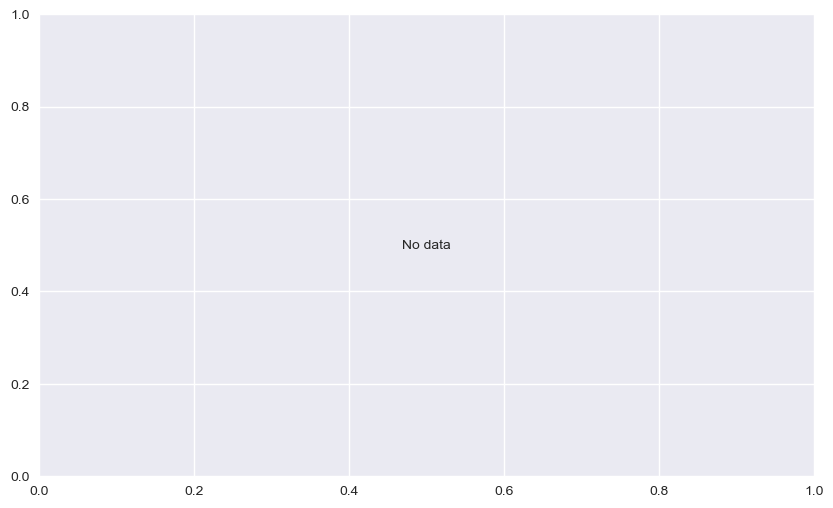

Hyperparameters for Best Runs
Saved hyperparameters to best_hyperparameters_regression_itr_0.csv


In [6]:
reg = load_task("regression")
show_results(*reg)